# **FCC-hh di-Higgs Analysis Project Part 2**

## This notebook is separated into different sections:
- **Section a)** Running the neural network! We use a Graph Attention Network but you don't need to know what that means.
- **Section b)** After initial running, adjust which higher order variables are input into the GNN and see if there is an improvement in output score.
- **Section c)** Compare the $S/\sqrt{B}$ to what you got using the cut and count method. Does using the model improve the significance?

In [1]:
# RUN FIRST
# Initialising Python Packages
import sys, os, torch
sys.path.insert(0, os.path.join(os.path.abspath(''), 'src'))

from sparticles.transforms import MakeHomogeneous
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATv2Conv, global_mean_pool

from sparticles.training_dataset  import CustomEventsDataset
from sparticles.model    import GAT
from sparticles.training import train, get_predictions, plot_training_curves, \
                     plot_roc_curve, plot_output_distribution, plot_significance
from sparticles.analysis import SIGNAL_SCALE, BACKGROUND_SCALE

## **Section a)**

First run the cells up until **Section c)** as is. What do you notice about the model output? 

## **Section b)**

After you've looked at this, add some additional variables into the dataset and see how this changes things. You can try and also look at varying the `sig_no` and `ttb_no` numbers to add more data into the input to the neural network.

The cell below will initialise download all the files we need for plotting and later on, the machine learning.

Set `delete_processed=True` whenever you change which variables are enabled.

In [11]:
sig_no   = 20000
ttb_no   = 20000
vjets_no = 0

dataset = CustomEventsDataset(
    root='./fcc_hh_data',
    url='https://cernbox.cern.ch/s/QoROVFN6wOrHWx0/download',
    delete_raw_archive=False,
    delete_processed=True,   # set True after changing any variable flags below
    add_edge_index=True,
    event_subsets={'signal': sig_no, 'vjets': vjets_no, 'ttbar': ttb_no},
    transform=MakeHomogeneous(),
    signal_filename='hhbbtata.h5',
    background_filename='mgp8_pp_tt012j_5f.h5',
    m_bb=True,  dR_bb=True,                     #   
    m_tt=True,  dR_tt=True,  dpT_tt=True,      #   <------ these are the variable flags that you should change!
    m_HH=False,  dPhi_HH=False,                   # 
)

print(f'Loaded {len(dataset)} events')

Deleted cached processed file: ./fcc_hh_data\processed\events_signal_20000_ttbar_20000_vjets_0__C_met_0_dPhi_HH_0_dR_bb_1_dR_tt_1_dpT_tt_1_m_HH_0_m_T_0_m_bb_1_m_tt_1.pt


Processing...
Processing ttbar events: 100%|██████████| 20000/20000 [00:17<00:00, 1117.12it/s]


Loaded 40000 events


Done!
C:\Users\Lennox\git_testing\fcc_ml_work_experience_liverpool\src\sparticles\dataset_edge_embed.py:229: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.data, self.sl

We split events into a **training set** (80%) that the model learns from and
a **test set** (20%) held back to check how well it generalises to unseen
events. The normalisation statistics are computed from the training set only,
to avoid any information from the test set leaking into training.

In [12]:
train_indices, test_indices = train_test_split(
    range(len(dataset)),
    train_size=0.8,
    stratify=[dataset.get(i).y.item() for i in range(len(dataset))],
    random_state=42,
)

dataset.fit_normalization(train_indices)

train_graphs = Subset(dataset, train_indices)
test_graphs  = Subset(dataset, test_indices)

train_loader = DataLoader(train_graphs, batch_size=500, shuffle=True)
test_loader  = DataLoader(test_graphs,  batch_size=500, shuffle=False)

print(f'Training: {len(train_graphs)} events  |  Test: {len(test_graphs)} events')

Training: 32000 events  |  Test: 8000 events


The model is a **Graph Attention Network**: each particle node attends to
its neighbours with learned weights, updating its representation based on
which connections matter most. After three rounds of message passing, the
whole graph is collapsed into one vector and classified as signal or background.

You can adjust `EPOCH_NUMBER` and `hidden_channels` below.

In [13]:
EPOCH_NUMBER    = 10    # more epochs = better performance, but takes longer
hidden_channels = 50    # width of the hidden layers

device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sig_weight = ttb_no / sig_no if sig_no > 0 and ttb_no > 0 else 1.0

# edge_dim is the number of edge features after MakeHomogeneous doubling
# (None if no edge variables are enabled)
active_edge_vars = dataset.active_edge_vars
edge_dim = len(active_edge_vars) * 2 if active_edge_vars else None

model = GAT(
    input_channels=dataset[0].data_norm.shape[1],
    hidden_channels=hidden_channels,
    num_classes=1,
    edge_dim=edge_dim,
)
model.to(device)
print(model)
print(f'\nTraining on: {device}')

optimizer = torch.optim.Adam(model.parameters(), lr=1e-7, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=5e-4, steps_per_epoch=len(train_loader),
    epochs=EPOCH_NUMBER, pct_start=0.01, div_factor=5000, final_div_factor=1e-2,
)

GAT(
  (conv1): GATv2Conv(6, 50, heads=1)
  (activation1): ReLU()
  (conv2): GATv2Conv(50, 50, heads=1)
  (activation2): ReLU()
  (conv3): GATv2Conv(50, 50, heads=1)
  (head): Linear(in_features=50, out_features=1, bias=True)
)

Training on: cpu


The model learns by adjusting its weights to minimise the loss function after
each batch of events. Run this cell and watch the loss decrease and accuracy
increase, this is a sign the model is learning to separate signal from background.

In [5]:
history = train(
    model, train_loader, test_loader,
    optimizer, scheduler,
    n_epochs=EPOCH_NUMBER,
    sig_weight=sig_weight,
    device=device,
)

Epoch   0 | Train loss: 0.641  acc: 67.0% | Test  loss: 0.629  acc: 63.2% | Time: 0.8 min


Epoch   1 | Train loss: 0.487  acc: 78.0% | Test  loss: 0.482  acc: 78.0% | Time: 1.5 min


Epoch   2 | Train loss: 0.598  acc: 69.0% | Test  loss: 0.476  acc: 78.0% | Time: 2.3 min


Epoch   3 | Train loss: 0.490  acc: 74.0% | Test  loss: 0.473  acc: 78.8% | Time: 3.0 min


Epoch   4 | Train loss: 0.471  acc: 75.0% | Test  loss: 0.468  acc: 78.2% | Time: 3.9 min


Epoch   5 | Train loss: 0.440  acc: 82.0% | Test  loss: 0.464  acc: 78.5% | Time: 4.6 min


Epoch   6 | Train loss: 0.462  acc: 77.0% | Test  loss: 0.468  acc: 78.5% | Time: 5.4 min


Epoch   7 | Train loss: 0.526  acc: 74.0% | Test  loss: 0.465  acc: 78.8% | Time: 6.2 min


Epoch   8 | Train loss: 0.438  acc: 84.0% | Test  loss: 0.465  acc: 78.8% | Time: 7.0 min


Epoch   9 | Train loss: 0.544  acc: 72.0% | Test  loss: 0.465  acc: 78.8% | Time: 7.7 min

Model saved to Saved Models/GAT_10epochs.pth


These training curves are used to check the loss and accuracy. Ideally, loss should decrease and accuracy should increase. A flat or rising loss suggests the model needs more epochs, more data, or different hyperparameters.

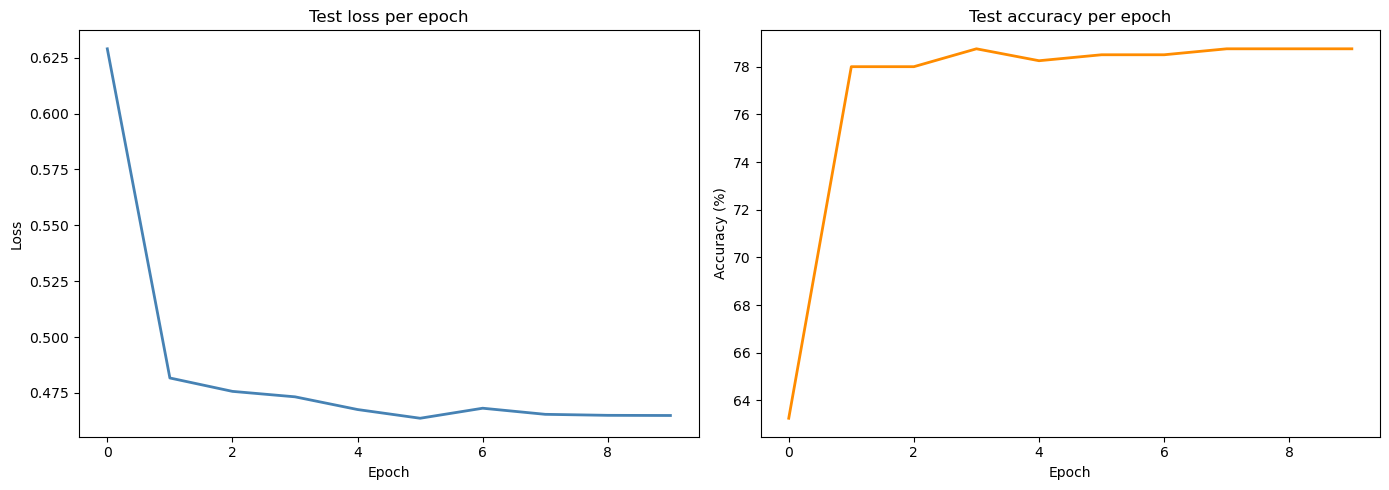

In [6]:
plot_training_curves(history)

The **ROC curve** shows signal efficiency vs background efficiency at every
possible score threshold. The **AUC** summarises this as one number — 1.0
is perfect, 0.5 is a random guess.

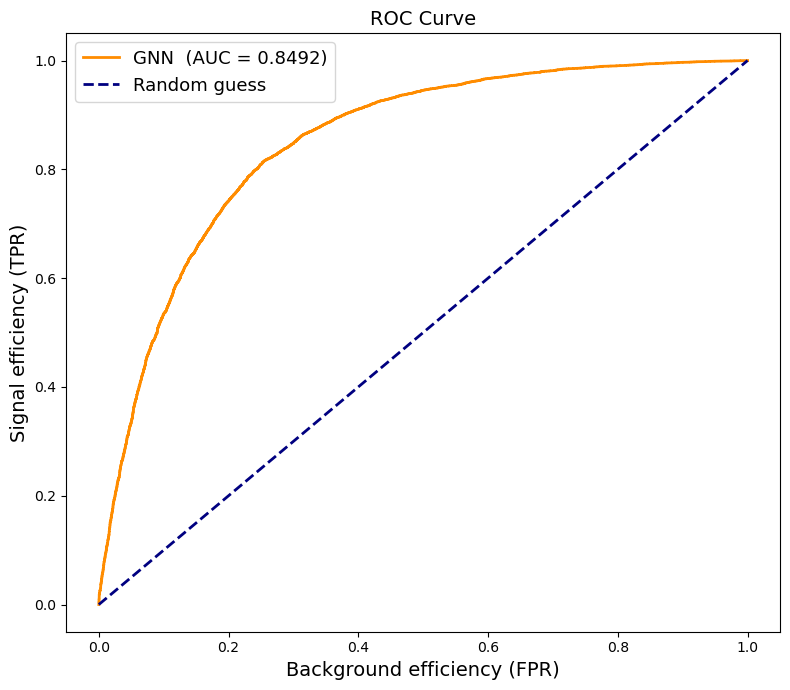

AUC = 0.8492


In [7]:
true_labels, predicted_probs = get_predictions(model, test_loader)
roc_auc = plot_roc_curve(true_labels, predicted_probs)
print(f'AUC = {roc_auc:.4f}')

Below is the model output distribution:

A well-trained model pushes signal scores towards 1 and background towards 0.
The more separated these two histograms are, the better the model is performing.

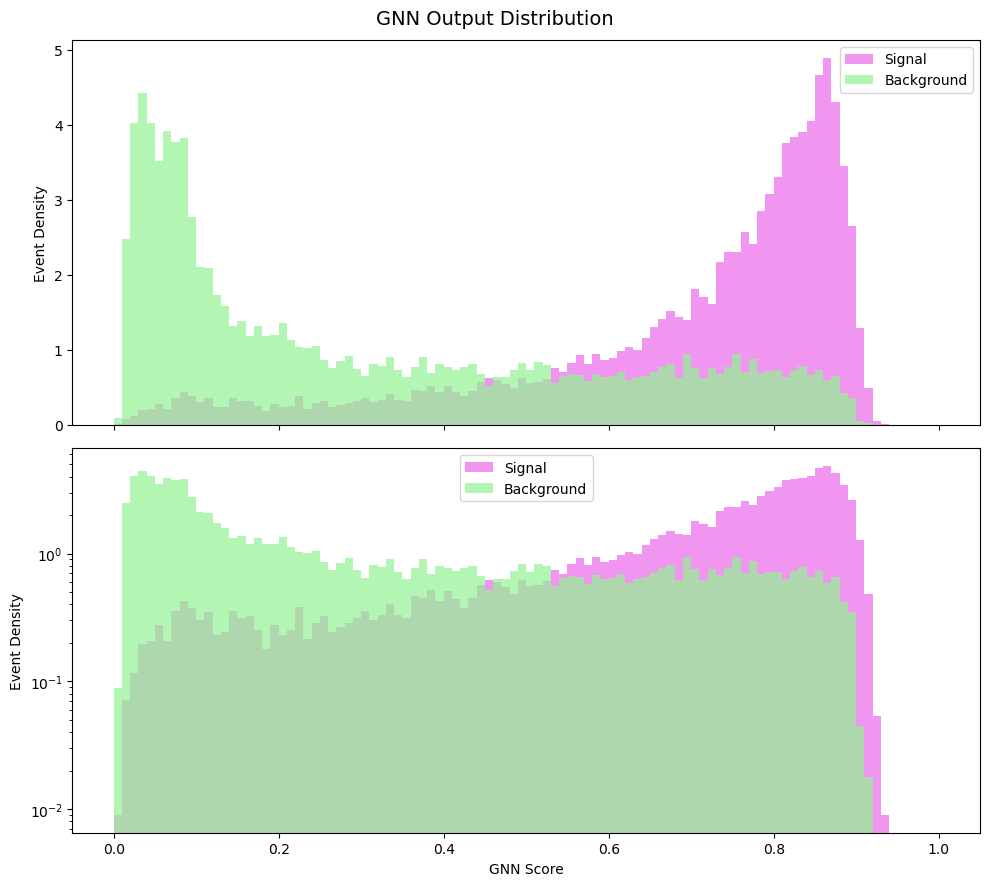

In [8]:
signal_probs, background_probs = plot_output_distribution(true_labels, predicted_probs)

## **Section c)**

Finally, we apply the physical event weights and calculate S/√B as a function
of the GNN score threshold, the peak tells you the optimal cut to apply.

How does this compare to the significance you achieved with manual cut and count method in the previous session?

Significance with no GNN cut:  6.04
Best cumulative significance:  12.22  (at GNN score > 0.01)
That is above 5σ — discovery territory!


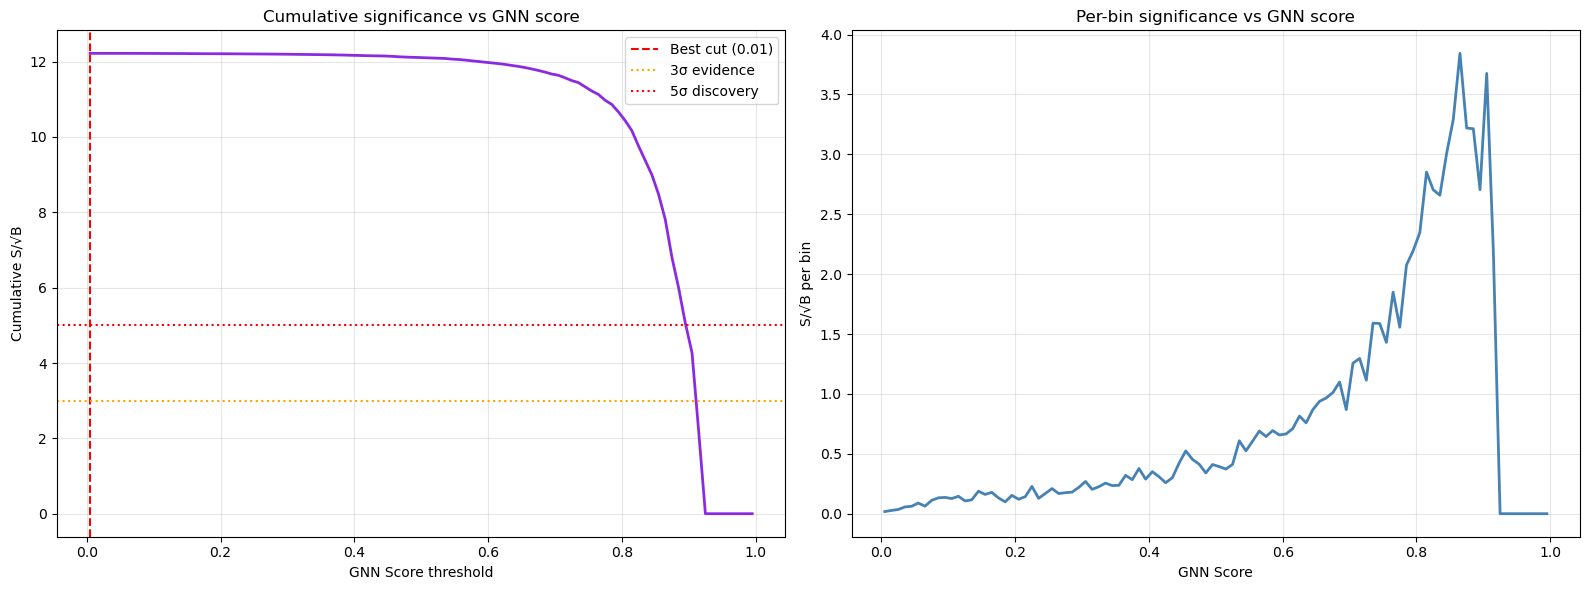

In [9]:
best_significance = plot_significance(
    signal_probs, background_probs,
    signal_scale=SIGNAL_SCALE,
    background_scale=BACKGROUND_SCALE,
    max_signal=MAX_SIGNAL_EVENTS,
    max_background=MAX_BACKGROUND_EVENTS,
)